<a href="https://colab.research.google.com/github/Sagar-Ramajinappa/virtual-work-lab-task04/blob/main/Task_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================================
# GEOSPATIAL DATA ANALYSIS AND BUSINESS EXPANSION PROJECT
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print("="*60)
print("GEOSPATIAL DATA ANALYSIS")
print("="*60)

GEOSPATIAL DATA ANALYSIS


In [2]:
# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------
df = pd.read_csv("geospatial_sales.csv")

print("\nDataset Shape:", df.shape)
print(df.head())


Dataset Shape: (5000, 10)
   StoreID        Date       City        State   Latitude  Longitude   Sales  \
0     1000  2025-01-13  Hyderabad    Telangana  17.423648  78.445883  123158   
1     1001  2025-01-17    Kolkata  West Bengal  22.497368  88.318882  314951   
2     1002  2025-08-03     Jaipur    Rajasthan  26.867670  75.801583  474374   
3     1003  2025-06-24    Kolkata  West Bengal  22.537059  88.318350  450290   
4     1004  2025-02-19    Kolkata  West Bengal  22.550037  88.338933  188685   

   Customers ExistingStore  DemandScore  
0        154           Yes           77  
1         77           Yes           85  
2         56           Yes           84  
3        394           Yes           45  
4         94            No           74  


In [3]:
# ----------------------------------------------------------
# Data Cleaning
# ----------------------------------------------------------
print("\nMissing Values")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

num_cols = df.select_dtypes(include=np.number).columns
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

cat_cols = df.select_dtypes(include="object").columns
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print("\nCleaned Dataset Shape:", df.shape)


Missing Values
StoreID          0
Date             0
City             0
State            0
Latitude         0
Longitude        0
Sales            0
Customers        0
ExistingStore    0
DemandScore      0
dtype: int64

Cleaned Dataset Shape: (5000, 10)


In [4]:
# ----------------------------------------------------------
# Dataset Information
# ----------------------------------------------------------
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   StoreID        5000 non-null   int64  
 1   Date           5000 non-null   object 
 2   City           5000 non-null   object 
 3   State          5000 non-null   object 
 4   Latitude       5000 non-null   float64
 5   Longitude      5000 non-null   float64
 6   Sales          5000 non-null   int64  
 7   Customers      5000 non-null   int64  
 8   ExistingStore  5000 non-null   object 
 9   DemandScore    5000 non-null   int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 390.8+ KB
None
           StoreID     Latitude    Longitude          Sales    Customers  \
count  5000.000000  5000.000000  5000.000000    5000.000000  5000.000000   
mean   3499.500000    20.921482    77.930116  275686.950200   324.322400   
std    1443.520003     5.308821     4.582017  130757.445542   157.82


Sales by City
City
Kolkata      149296120
Jaipur       142480048
Pune         142323643
Chennai      140714715
Lucknow      138251382
Bengaluru    137150995
Ahmedabad    136745702
Delhi        134277478
Mumbai       130063531
Hyderabad    127131137
Name: Sales, dtype: int64


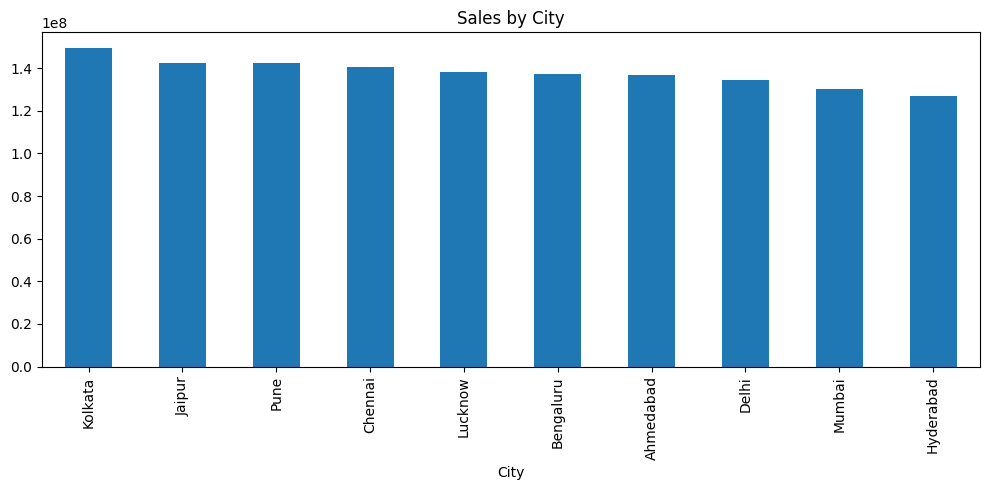

In [5]:
# ----------------------------------------------------------
# Sales by City
# ----------------------------------------------------------
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)
print("\nSales by City")
print(city_sales)

plt.figure(figsize=(10,5))
city_sales.plot(kind="bar")
plt.title("Sales by City")
plt.tight_layout()
plt.savefig("sales_by_city.png")
plt.show()

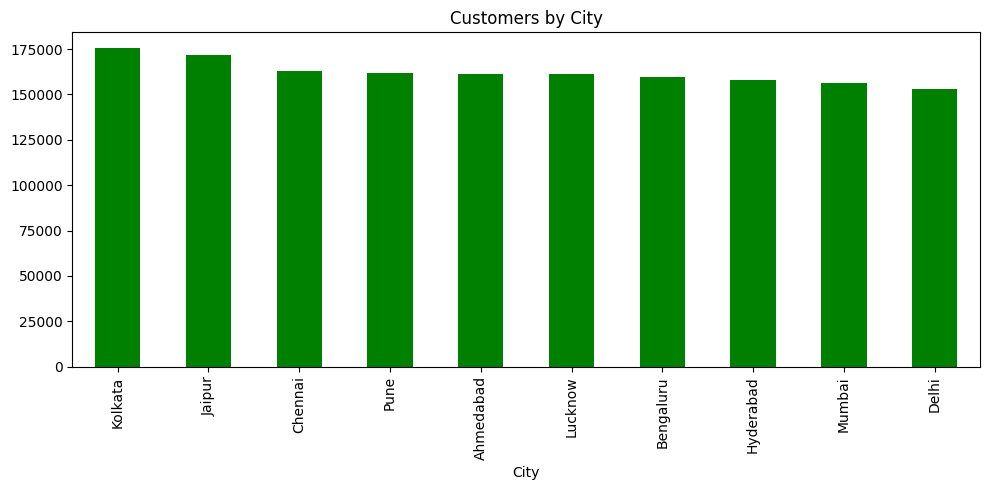

In [6]:
# ----------------------------------------------------------
# Customers by City
# ----------------------------------------------------------
city_customers = df.groupby("City")["Customers"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
city_customers.plot(kind="bar", color="green")
plt.title("Customers by City")
plt.tight_layout()
plt.savefig("customers_by_city.png")
plt.show()

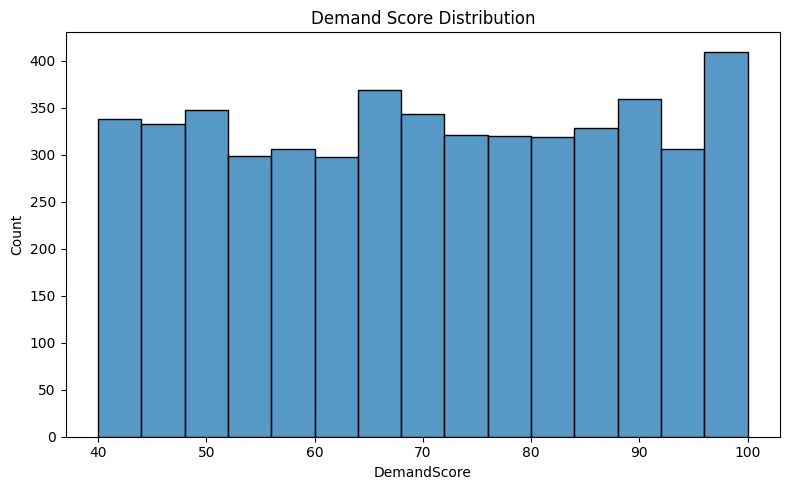

In [7]:
# ----------------------------------------------------------
# Demand Score Distribution
# ----------------------------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["DemandScore"], bins=15)
plt.title("Demand Score Distribution")
plt.tight_layout()
plt.savefig("demand_distribution.png")
plt.show()

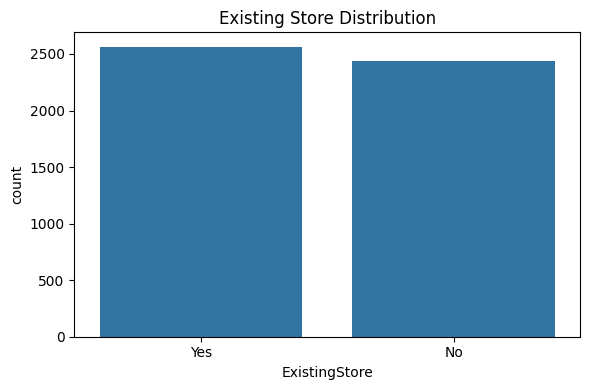

In [8]:
# ----------------------------------------------------------
# Existing Store Distribution
# ----------------------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="ExistingStore")
plt.title("Existing Store Distribution")
plt.tight_layout()
plt.savefig("existing_store.png")
plt.show()

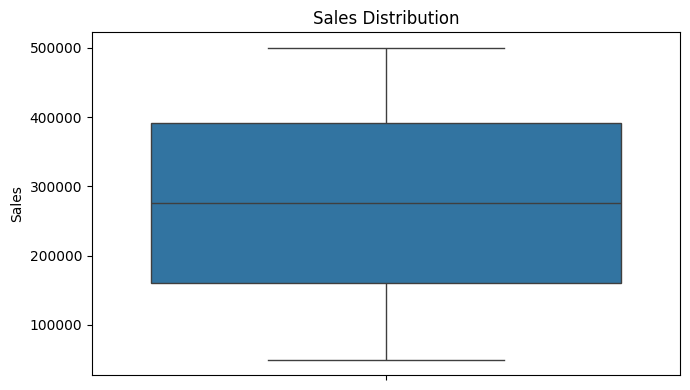

In [9]:
# ----------------------------------------------------------
# Sales Distribution
# ----------------------------------------------------------
plt.figure(figsize=(7,4))
sns.boxplot(y=df["Sales"])
plt.title("Sales Distribution")
plt.tight_layout()
plt.savefig("sales_distribution.png")
plt.show()

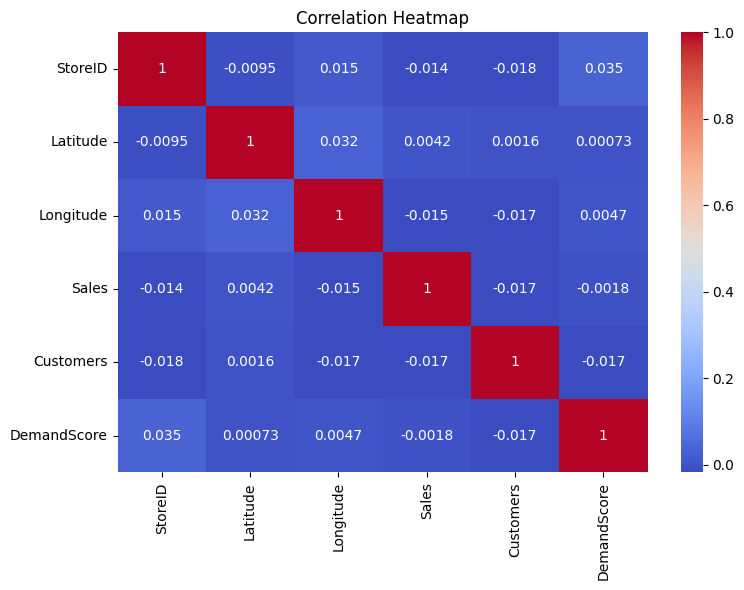

In [10]:
# ----------------------------------------------------------
# Correlation Heatmap
# ----------------------------------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()


Recommended Expansion Locations
City
Jaipur       108
Kolkata      104
Ahmedabad     92
Chennai       91
Pune          87
Bengaluru     86
Lucknow       85
Hyderabad     75
Mumbai        75
Delhi         71
dtype: int64


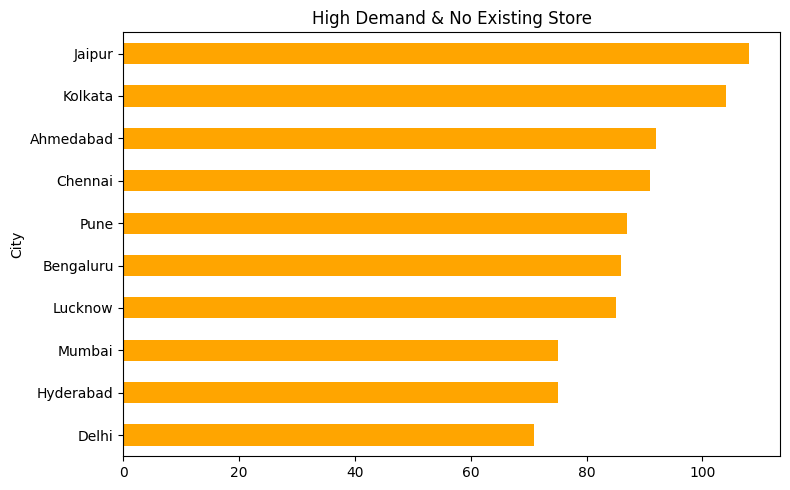

In [11]:
# ----------------------------------------------------------
# High Demand - Low Presence
# ----------------------------------------------------------
expansion = df[(df["DemandScore"] >= 80) &
               (df["ExistingStore"]=="No")]

print("\nRecommended Expansion Locations")
print(expansion.groupby("City").size().sort_values(ascending=False))

plt.figure(figsize=(8,5))
expansion.groupby("City").size().sort_values().plot(kind="barh", color="orange")
plt.title("High Demand & No Existing Store")
plt.tight_layout()
plt.savefig("expansion_locations.png")
plt.show()

In [12]:
# ----------------------------------------------------------
# Interactive Sales Map
# ----------------------------------------------------------
m = folium.Map(location=[22.5,79], zoom_start=5)

for _,r in df.iterrows():
    folium.CircleMarker(
        location=[r["Latitude"],r["Longitude"]],
        radius=4,
        popup=f"{r['City']}<br>Sales:{r['Sales']}",
        color="blue",
        fill=True
    ).add_to(m)

m.save("Sales_Map.html")
print("Sales_Map.html created")

Sales_Map.html created


In [13]:
# ----------------------------------------------------------
# Heat Map
# ----------------------------------------------------------
heat = folium.Map(location=[22.5,79], zoom_start=5)
HeatMap(df[["Latitude","Longitude","Sales"]].values.tolist()).add_to(heat)
heat.save("Heat_Map.html")
print("Heat_Map.html created")

Heat_Map.html created



Random Forest Accuracy
0.627

Classification Report
              precision    recall  f1-score   support

           0       0.65      0.90      0.76       644
           1       0.43      0.14      0.21       356

    accuracy                           0.63      1000
   macro avg       0.54      0.52      0.48      1000
weighted avg       0.57      0.63      0.56      1000


Feature Importance
     Feature  Importance
2      Sales    0.258299
1  Longitude    0.251437
0   Latitude    0.249597
3  Customers    0.240667


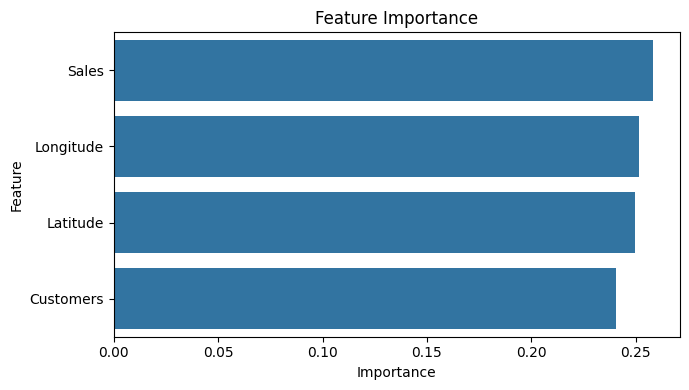

In [14]:
# ----------------------------------------------------------
# Machine Learning
# Predict High Demand Locations
# ----------------------------------------------------------
df["HighDemand"] = (df["DemandScore"]>=80).astype(int)

features = ["Latitude","Longitude","Sales","Customers"]
X = df[features]
y = df["HighDemand"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("\nRandom Forest Accuracy")
print(accuracy_score(y_test,pred))

print("\nClassification Report")
print(classification_report(y_test,pred))

importance = pd.DataFrame({
    "Feature":features,
    "Importance":model.feature_importances_
}).sort_values("Importance",ascending=False)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(7,4))
sns.barplot(data=importance,
            x="Importance",
            y="Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [15]:
# ----------------------------------------------------------
# Top 10 Sales Cities
# ----------------------------------------------------------
print("\nTop 10 Sales Cities")
print(city_sales.head(10))


Top 10 Sales Cities
City
Kolkata      149296120
Jaipur       142480048
Pune         142323643
Chennai      140714715
Lucknow      138251382
Bengaluru    137150995
Ahmedabad    136745702
Delhi        134277478
Mumbai       130063531
Hyderabad    127131137
Name: Sales, dtype: int64


In [16]:
# ----------------------------------------------------------
# Save Clean Dataset
# ----------------------------------------------------------
df.to_csv("clean_geospatial_sales.csv",index=False)

In [17]:
# ----------------------------------------------------------
# Business Insights
# ----------------------------------------------------------
print("""
============================================================
BUSINESS INSIGHTS
============================================================
1. Cities with highest sales should be considered for new
   branches or larger inventory.

2. Cities with DemandScore >= 80 and ExistingStore = No
   are ideal business expansion targets.

3. Higher customer counts generally indicate stronger
   market potential.

4. Heat maps reveal customer concentration.

5. Correlation analysis helps understand relationships
   between sales, customers and demand.

6. Random Forest predicts high-demand locations using
   sales and customer information.

Output Files:
--------------
clean_geospatial_sales.csv
sales_by_city.png
customers_by_city.png
demand_distribution.png
correlation_heatmap.png
feature_importance.png
Sales_Map.html
Heat_Map.html
============================================================
""")


BUSINESS INSIGHTS
1. Cities with highest sales should be considered for new
   branches or larger inventory.

2. Cities with DemandScore >= 80 and ExistingStore = No
   are ideal business expansion targets.

3. Higher customer counts generally indicate stronger
   market potential.

4. Heat maps reveal customer concentration.

5. Correlation analysis helps understand relationships
   between sales, customers and demand.

6. Random Forest predicts high-demand locations using
   sales and customer information.

Output Files:
--------------
clean_geospatial_sales.csv
sales_by_city.png
customers_by_city.png
demand_distribution.png
correlation_heatmap.png
feature_importance.png
Sales_Map.html
Heat_Map.html

